In [ ]:
def convert_atm(P, u):
    if u == "gcms2":
        return P/1013.25 * 10**-3
    elif u == "mbar":
        return P/1013.25
def convert_vmr(ppm):
    return ppm * 1e-6

Comprobamos que "preassure" viene siendo P_total, por lo cual la suma de los q deberia dar 1

In [ ]:
'''Midlatitude Summer'''
Ptotal = convert_atm(1.013e6, "gcms2") 
ppVs = [1.876E-02, 3.300E-04, 3.017E-08, 3.200E-07, 1.500E-07, 1.700E-06, 0.781]
o2 = convert_vmr(2.090E+05)
vmrs = ppVs + [o2]
print(vmrs)

[0.01876, 0.00033, 3.017e-08, 3.2e-07, 1.5e-07, 1.7e-06, 0.781, 0.209]


In [87]:
sum(vmrs)

1.00909220017

El valor de N₂ (0.781) muy probablemente ya incluye el Argón y otros gases nobles

En la atmósfera real, la presencia de vapor de agua (H₂O = 0.01876) hace que la suma de fracciones volumétricas pueda ser ligeramente mayor que 1

Puede haber pequeños redondeos en los datos del perfil

In [89]:
a = [1.876e+04/1e6, 330/1e6, 0.03017/1e6, 0.32/1e6, 0.15/1e6, 1.7/1e6, 0.20946]
sum(a)

0.22855220017

**Calculando los Pmol**

In [94]:
Pmol_values = [pmol*Ptotal for pmol in vmrs]
print(Ptotal)
print(Pmol_values)
print(sum(Pmol_values))
print(sum(vmrs))

0.999753269183321
[0.0187553713298791, 0.0003299185788304959, 3.016255613126079e-08, 3.1992104613866274e-07, 1.4996299037749815e-07, 1.6995805576116458e-06, 0.7808073032321737, 0.2089484332593141]
1.0088432260273477
1.00909220017


Calculando firma

c:\Users\PC\Documents\GitHub\Stand-off
DEBUG: H2O qfile=TIPS/q1.txt exists=True
DEBUG: CO2 qfile=TIPS/q7.txt exists=True
DEBUG: O3 qfile=TIPS/q16.txt exists=True
DEBUG: N2O qfile=TIPS/q21.txt exists=True
DEBUG: CO qfile=TIPS/q26.txt exists=True
DEBUG: CH4 qfile=TIPS/q32.txt exists=True
DEBUG: O2 qfile=TIPS/q36.txt exists=True


c:\Users\PC\Documents\GitHub\Stand-off\final_forward_attenuation.py:39: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(qfile, header=None, delim_whitespace=True, comment='#')
c:\Users\PC\Documents\GitHub\Stand-off\final_forward_attenuation.py:39: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(qfile, header=None, delim_whitespace=True, comment='#')
c:\Users\PC\Documents\GitHub\Stand-off\final_forward_attenuation.py:39: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(qfile, header=None, delim_whitespace=True, comment='#')
c:\Users\PC\Documents\GitHub\Stand-off\final_forward_attenuation.py:39: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv 

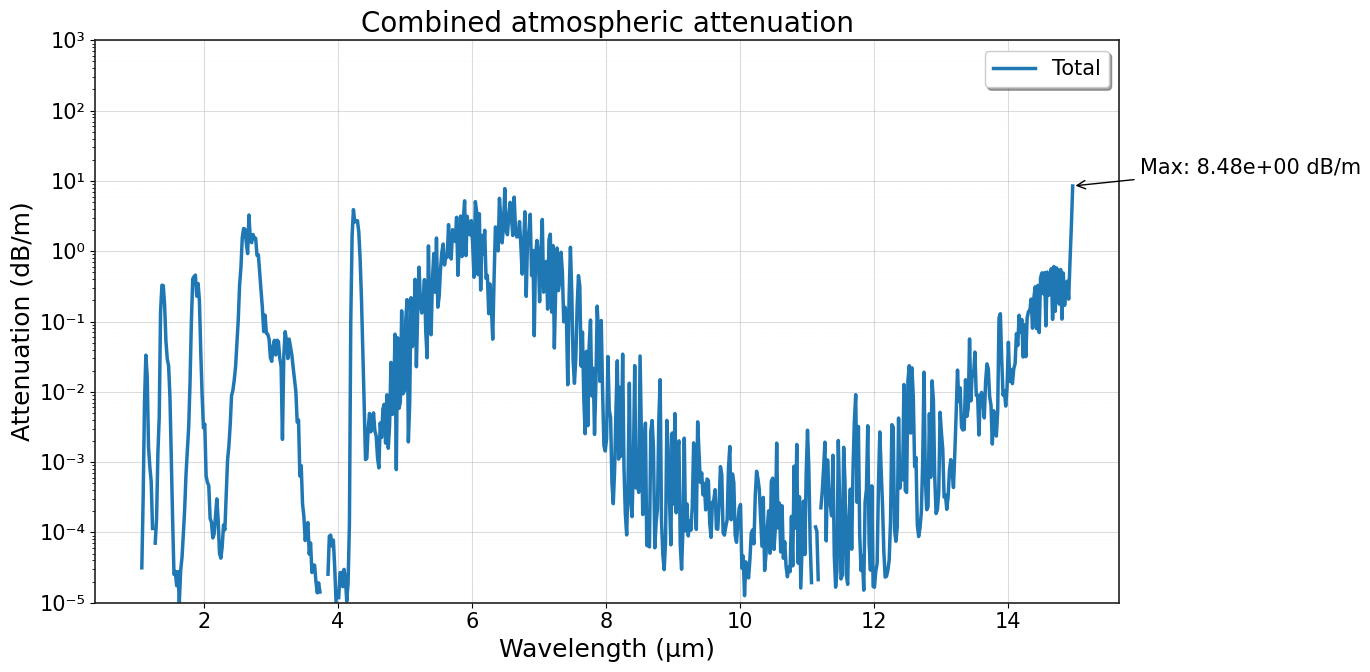

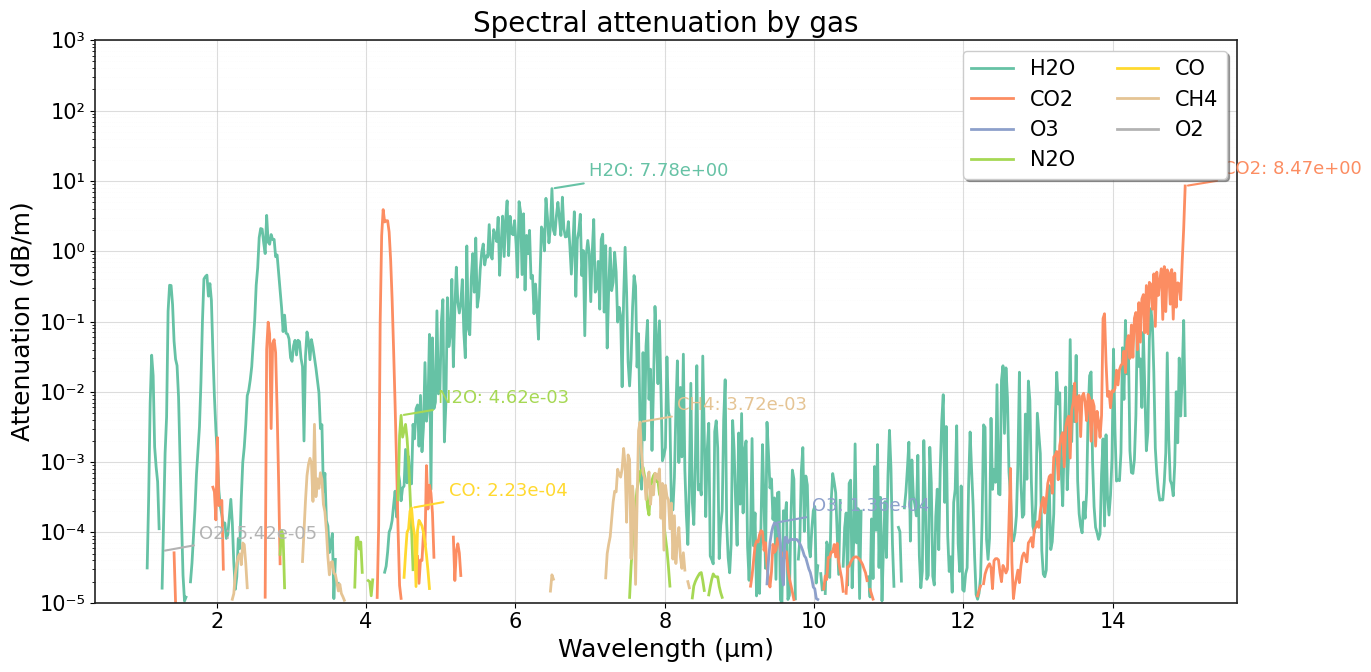

In [95]:
#Julian
import importlib
import final_forward_attenuation
importlib.reload(final_forward_attenuation)
from final_forward_attenuation import run_simulation, default_species

# Carga de isopologues (por si quieres usarlos explícitamente)
qfileH2O = 'TIPS\q1.txt'
qfileCO2 = 'TIPS\q7.txt'
qfileO3  = 'TIPS\q16.txt'
qfileN2O = 'TIPS\q21.txt'
qfileCO  = 'TIPS\q26.txt'
qfileCH4 = 'TIPS\q32.txt'
qfileO2  = 'TIPS\q36.txt'

sp = default_species()
for s in sp:
     if s.name == 'H2O': s.Pmol = 1.876e+04/1e6 #Esta mal, para mi
     if s.name == 'CO2': s.Pmol = 330/1e6
     if s.name == 'O3': s.Pmol = 0.03017/1e6
     if s.name == 'N2O': s.Pmol = 0.32/1e6
     if s.name == 'CO': s.Pmol = 0.15/1e6
     if s.name == 'CH4': s.Pmol = 1.7/1e6
     if s.name == 'O2': s.Pmol = 0.20946


import os
print(os.getcwd())

res = run_simulation(
    parfile='68da838c.par',
    species=sp,
    nu_min=666.67, nu_max=10000.0, dnu=0.01,
    tileW=20.0, guard=5.0,
    temp_K=296.0, L_m=1.0, Pair=1.0,
    delta_um=0.020,
    save_csv=True, outdir='out', make_plots=True,
)

lambda_um = res['lambda_centers']
Tprod = res['T_prod_samp']
Th2o  = res['T_each_samp'][0]

c:\Users\PC\Documents\GitHub\Stand-off
DEBUG: H2O qfile=TIPS/q1.txt exists=True
DEBUG: CO2 qfile=TIPS/q7.txt exists=True
DEBUG: O3 qfile=TIPS/q16.txt exists=True
DEBUG: N2O qfile=TIPS/q21.txt exists=True
DEBUG: CO qfile=TIPS/q26.txt exists=True
DEBUG: CH4 qfile=TIPS/q32.txt exists=True
DEBUG: O2 qfile=TIPS/q36.txt exists=True


c:\Users\PC\Documents\GitHub\Stand-off\final_forward_attenuation.py:39: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(qfile, header=None, delim_whitespace=True, comment='#')
c:\Users\PC\Documents\GitHub\Stand-off\final_forward_attenuation.py:39: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(qfile, header=None, delim_whitespace=True, comment='#')
c:\Users\PC\Documents\GitHub\Stand-off\final_forward_attenuation.py:39: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(qfile, header=None, delim_whitespace=True, comment='#')
c:\Users\PC\Documents\GitHub\Stand-off\final_forward_attenuation.py:39: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv 

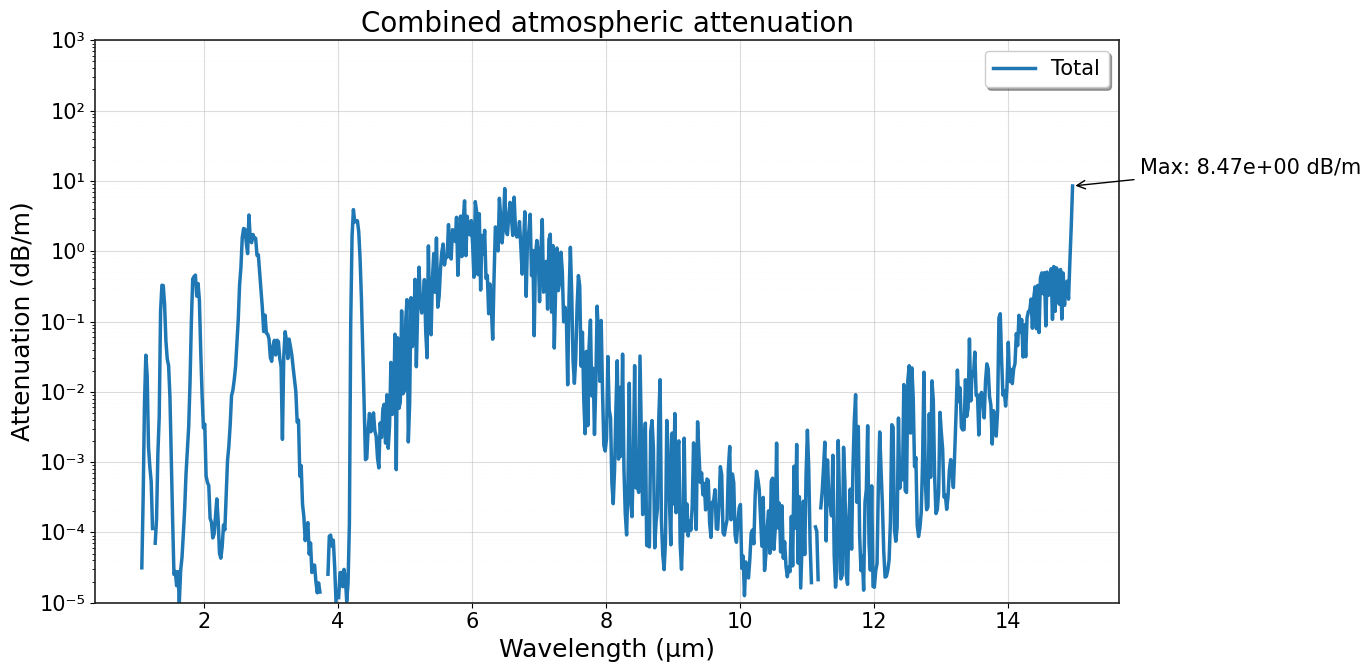

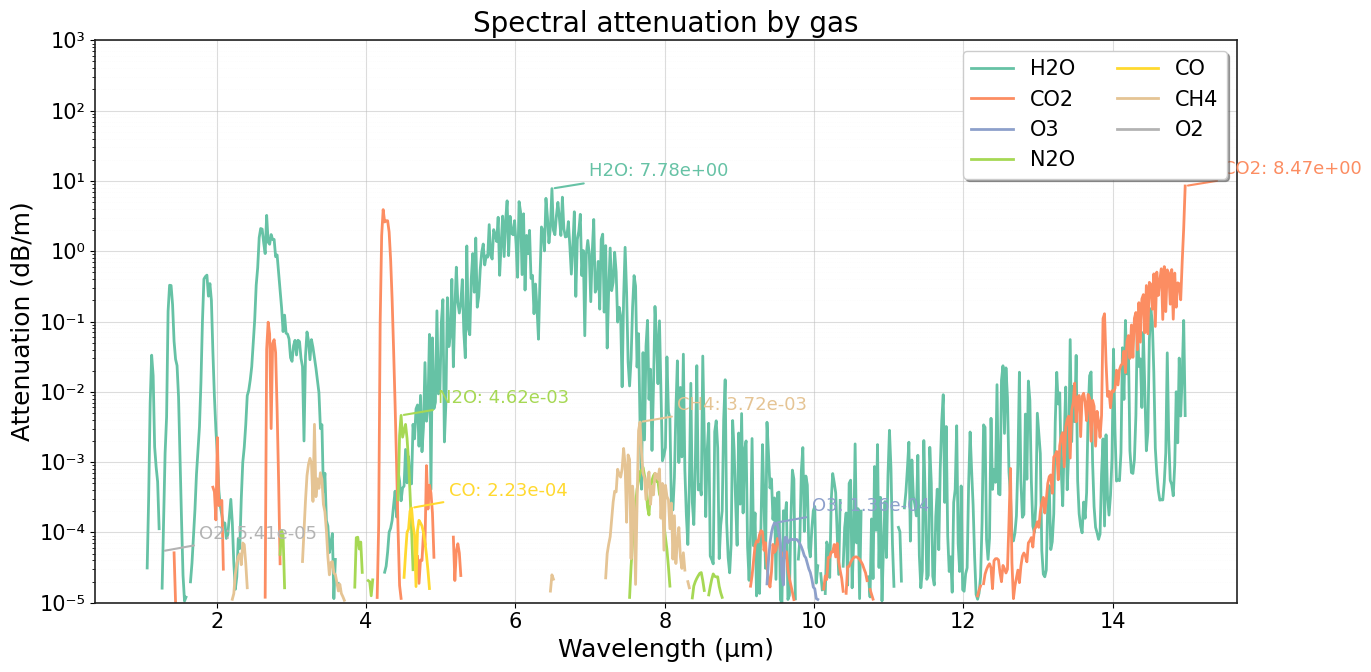

In [96]:
#Nuevos valores
import importlib
import final_forward_attenuation
importlib.reload(final_forward_attenuation)
from final_forward_attenuation import run_simulation, default_species

# Carga de isopologues (por si quieres usarlos explícitamente)
qfileH2O = 'TIPS\q1.txt'
qfileCO2 = 'TIPS\q7.txt'
qfileO3  = 'TIPS\q16.txt'
qfileN2O = 'TIPS\q21.txt'
qfileCO  = 'TIPS\q26.txt'
qfileCH4 = 'TIPS\q32.txt'
qfileO2  = 'TIPS\q36.txt'

sp = default_species()
for s in sp:
     if s.name == 'H2O': s.Pmol = 0.0187553713298791
     if s.name == 'CO2': s.Pmol = 0.0003299185788304959
     if s.name == 'O3': s.Pmol = 3.016255613126079e-08
     if s.name == 'N2O': s.Pmol = 3.1992104613866274e-07
     if s.name == 'CO': s.Pmol = 1.4996299037749815e-07
     if s.name == 'CH4': s.Pmol = 1.6995805576116458e-06
     if s.name == 'O2': s.Pmol = 0.2089484332593141


import os
print(os.getcwd())

res = run_simulation(
    parfile='68da838c.par',
    species=sp,
    nu_min=666.67, nu_max=10000.0, dnu=0.01,
    tileW=20.0, guard=5.0,
    temp_K=296.0, L_m=1.0, Pair=1.0,
    delta_um=0.020,
    save_csv=True, outdir='out', make_plots=True,
)

lambda_um = res['lambda_centers']
Tprod = res['T_prod_samp']
Th2o  = res['T_each_samp'][0]

In [104]:
#OTRO VALOR DE P si va a afectar
a = convert_atm(0.6250, "gcms2")
print(a)

6.16827041697508e-07
